  Dataset chargé : 122,171 lignes × 23 colonnes
  Features disponibles : ['FlowDuration/s', 'SrcAddr', 'SrcPort', 'DstAddr', 'DstPort', 'Protocol', 'TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'PacketDropRate', 'AverageHopCount', 'label', 'label_encoded']
    Mapping M/C/P défini
   Dimension M : 10 features
   Dimension C : 7 features
   Dimension P : 4 features
 Tableau de mapping M/C/P — UAVIDS-2025 :

        Feature Dimension                                                                    Justification
AverageHopCount         C                Nombre de sauts moyen — composant protocole de routage AODV ciblé
        SrcAddr         C           Adresse source — composant identité du nœud (Sybil = fausses adresses)
        DstAddr         C                          Adresse destination — composant nœud destinataire ciblé
        S

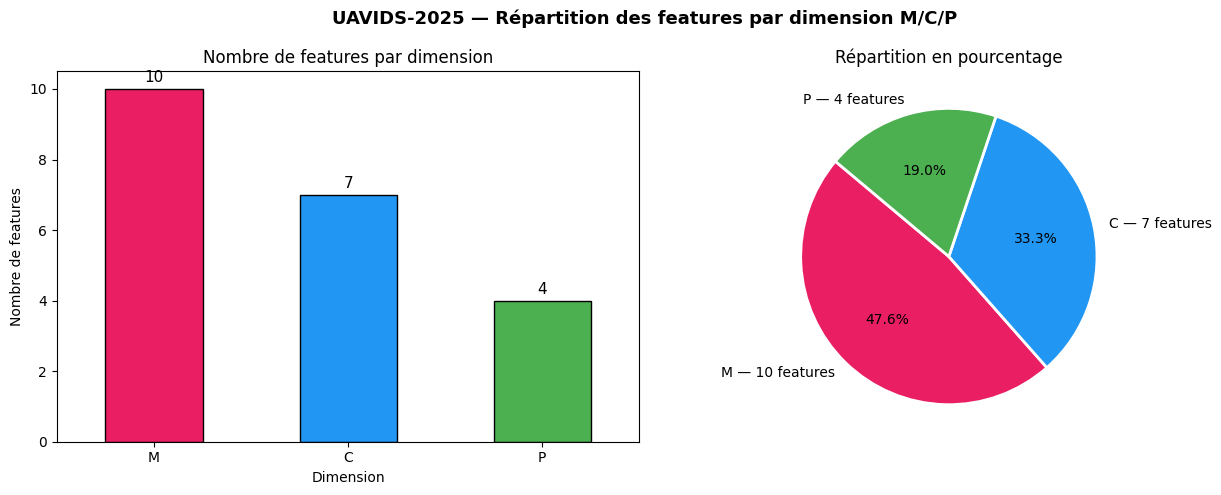

    Features M (Mécanisme)  : ['TxPackets', 'RxPackets', 'LostPackets', 'TxPacketRate/s', 'RxPacketRate/s', 'PacketDropRate', 'TxBytes', 'RxBytes', 'TxByteRate/s', 'RxByteRate/s']

  Features C (Composant)  : ['AverageHopCount', 'SrcAddr', 'DstAddr', 'SrcPort', 'DstPort', 'Protocol', 'MeanPacketSize']

  Features P (Paramètre)  : ['FlowDuration/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps']

 Features M présentes dans le dataset : ['TxPackets', 'RxPackets', 'LostPackets', 'TxPacketRate/s', 'RxPacketRate/s', 'PacketDropRate', 'TxBytes', 'RxBytes', 'TxByteRate/s', 'RxByteRate/s']
  Features C présentes dans le dataset : ['AverageHopCount', 'SrcAddr', 'DstAddr', 'SrcPort', 'DstPort', 'Protocol', 'MeanPacketSize']
 Features P présentes dans le dataset : ['FlowDuration/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps']
 Moyennes des features M par classe :

                  TxPackets  RxPackets  LostPackets  TxPacketRate/s  RxPacketRate/s  PacketDropRate  TxBytes  RxBytes  TxByte

In [2]:
# ============================================================
# NOTEBOOK : Mapping M/C/P — UAVIDS-2025
# ============================================================
# ────────────────────────────────────────
# 1. IMPORTATION DES LIBRAIRIES
# ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────
# 2. CHARGEMENT DU DATASET NETTOYÉ
# ────────────────────────────────────────
FILE_PATH = r"C:\Drone_Attack_Similarity_Project\Rapport\tables\UAVIDS-2025_clean.csv"
df = pd.read_csv(FILE_PATH)
print(f"  Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"  Features disponibles : {df.columns.tolist()}")

# ────────────────────────────────────────
# 3. DÉFINITION DU MAPPING M/C/P
# ────────────────────────────────────────
mapping_uavids = {

    # ── M : MÉCANISME D'ATTAQUE ──────────────────────────────
    # Ces features décrivent COMMENT l'attaque agit
    # (injection de paquets, suppression, manipulation du trafic)

    'TxPackets'       : ('M', 'Nombre total de paquets transmis — '
                               'révèle une injection massive (Flooding/Sybil)'),
    'RxPackets'       : ('M', 'Nombre total de paquets reçus — '
                               'chute révèle un Blackhole'),
    'LostPackets'     : ('M', 'Paquets perdus — '
                               'indicateur direct du mécanisme Blackhole'),
    'TxPacketRate/s'  : ('M', 'Taux d\'envoi de paquets/s — '
                               'élevé = mécanisme Flooding ou Sybil'),
    'RxPacketRate/s'  : ('M', 'Taux de réception — '
                               'faible = mécanisme Blackhole actif'),
    'PacketDropRate'  : ('M', 'Taux de perte — '
                               'mécanisme central du Blackhole'),
    'TxBytes'         : ('M', 'Volume total envoyé — '
                               'grand volume = mécanisme Flooding'),
    'RxBytes'         : ('M', 'Volume total reçu — '
                               'chute = mécanisme Blackhole'),
    'TxByteRate/s'    : ('M', 'Débit d\'envoi — '
                               'élevé = mécanisme d\'inondation'),
    'RxByteRate/s'    : ('M', 'Débit de réception — '
                               'faible = suppression active'),

    # ── C : COMPOSANT CIBLÉ ──────────────────────────────────
    # Ces features décrivent QUEL élément réseau est affecté
    # (protocole de routage, nœud, interface réseau)

    'AverageHopCount' : ('C', 'Nombre de sauts moyen — '
                               'composant protocole de routage AODV ciblé'),
    'SrcAddr'         : ('C', 'Adresse source — '
                               'composant identité du nœud (Sybil = fausses adresses)'),
    'DstAddr'         : ('C', 'Adresse destination — '
                               'composant nœud destinataire ciblé'),
    'SrcPort'         : ('C', 'Port source — '
                               'composant interface de communication'),
    'DstPort'         : ('C', 'Port destination — '
                               'composant service réseau ciblé'),
    'Protocol'        : ('C', 'Protocole réseau utilisé — '
                               'composant couche réseau (AODV, UDP, TCP)'),
    'MeanPacketSize'  : ('C', 'Taille moyenne des paquets — '
                               'composant structure des données échangées'),

    # ── P : PARAMÈTRE D'EXÉCUTION ────────────────────────────
    # Ces features décrivent les VALEURS MESURABLES qui
    # caractérisent et paramétrisent le comportement de l'attaque

    'FlowDuration/s'  : ('P', 'Durée du flux — '
                               'paramètre temporel de l\'attaque'),
    'MeanDelay/s'     : ('P', 'Délai moyen — '
                               'paramètre de latence introduit par l\'attaque'),
    'MeanJitter/s'    : ('P', 'Variation du délai — '
                               'paramètre de stabilité du réseau'),
    'Throughput/Kbps' : ('P', 'Débit effectif — '
                               'paramètre de performance réseau dégradé'),
}

print("    Mapping M/C/P défini")
print(f"   Dimension M : {sum(1 for v in mapping_uavids.values() if v[0]=='M')} features")
print(f"   Dimension C : {sum(1 for v in mapping_uavids.values() if v[0]=='C')} features")
print(f"   Dimension P : {sum(1 for v in mapping_uavids.values() if v[0]=='P')} features")


# ────────────────────────────────────────
# 4. CRÉATION DU TABLEAU DE MAPPING
# ────────────────────────────────────────
rows = []
for feature, (dimension, justification) in mapping_uavids.items():
    rows.append({
        'Feature'      : feature,
        'Dimension'    : dimension,
        'Justification': justification
    })

mapping_df = pd.DataFrame(rows).sort_values('Dimension')

print(" Tableau de mapping M/C/P — UAVIDS-2025 :\n")
print(mapping_df.to_string(index=False))

# ────────────────────────────────────────
# 5. VISUALISATION DU MAPPING
# ────────────────────────────────────────
counts = mapping_df['Dimension'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("UAVIDS-2025 — Répartition des features par dimension M/C/P",
             fontsize=13, fontweight='bold')

colors = {'M': '#E91E63', 'C': '#2196F3', 'P': '#4CAF50'}
color_list = [colors[d] for d in counts.index]

# Barplot
counts.plot(kind='bar', ax=axes[0], color=color_list,
            edgecolor='black', width=0.5)
axes[0].set_title("Nombre de features par dimension")
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Nombre de features")
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontsize=11)
    
# Pie chart
axes[1].pie(counts.values,
            labels=[f"{d} — {v} features" for d, v in zip(counts.index, counts.values)],
            autopct='%1.1f%%',
            colors=color_list,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("UAVIDS2025_mapping_MCP.png", dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────
# 6. EXTRACTION DES FEATURES PAR DIMENSION
# ────────────────────────────────────────
features_M = mapping_df[mapping_df['Dimension'] == 'M']['Feature'].tolist()
features_C = mapping_df[mapping_df['Dimension'] == 'C']['Feature'].tolist()
features_P = mapping_df[mapping_df['Dimension'] == 'P']['Feature'].tolist()

print(f"    Features M (Mécanisme)  : {features_M}")
print(f"\n  Features C (Composant)  : {features_C}")
print(f"\n  Features P (Paramètre)  : {features_P}")

# Filtrer uniquement les colonnes présentes dans le dataset
features_M_ok = [f for f in features_M if f in df.columns]
features_C_ok = [f for f in features_C if f in df.columns]
features_P_ok = [f for f in features_P if f in df.columns]

print(f"\n Features M présentes dans le dataset : {features_M_ok}")
print(f"  Features C présentes dans le dataset : {features_C_ok}")
print(f" Features P présentes dans le dataset : {features_P_ok}")

# ────────────────────────────────────────
# 7. STATISTIQUES PAR DIMENSION ET PAR CLASSE
# ────────────────────────────────────────
label_col = 'label' if 'label' in df.columns else 'label_encoded'

print(" Moyennes des features M par classe :\n")
if features_M_ok:
    print(df.groupby(label_col)[features_M_ok].mean().round(3).to_string())

print("\n Moyennes des features P par classe :\n")
if features_P_ok:
    print(df.groupby(label_col)[features_P_ok].mean().round(3).to_string())